# 02 Data Preparation

This notebook consolidates the two data sources into a single dataset, then
cleans and pre-processes the text in preparation for the NLP analysis carried
out in the next notebook.

The two sources enter with different fields, reflecting what each platform
provides. Trustpilot reviews carry a star rating and a title, collected from
saved review pages. Geekzone posts carry the topic URL, collected by re-reading
each forum topic and capturing the publication date of every post. Both sources
share the provider, source, text, and date fields. The fields that are specific
to one source are kept and left empty for the other, with the source column
marking the origin of each entry.

Both datasets cover the same 36-month window, from June 2023 to June 2026. The
Trustpilot data was filtered to this window during its own collection, and the
Geekzone data was filtered to the same window during the re-collection described
in the previous notebook.

## 1. Loading the Two Sources

Each source is loaded and inspected before consolidation, to confirm its size,
its columns, and that its dates fall inside the expected window. Inspecting both
separately at this point makes any mismatch visible before the two are combined.

In [1]:
import pandas as pd

# Load the two prepared sources.
trustpilot = pd.read_csv('trustpilot_all_36months.csv')
geekzone = pd.read_csv('geekzone_filtered.csv')

# Parse the date columns so dates are real dates, not text.
trustpilot['date'] = pd.to_datetime(trustpilot['date'], errors='coerce')
geekzone['date'] = pd.to_datetime(geekzone['date'], errors='coerce')

# Inspect Trustpilot.
print("TRUSTPILOT")
print(f"  Rows: {len(trustpilot)}")
print(f"  Columns: {list(trustpilot.columns)}")
print(f"  Date range: {trustpilot['date'].min().date()} to {trustpilot['date'].max().date()}")
print(f"  Per provider: {trustpilot['provider'].value_counts().to_dict()}")
print()

# Inspect Geekzone.
print("GEEKZONE")
print(f"  Rows: {len(geekzone)}")
print(f"  Columns: {list(geekzone.columns)}")
print(f"  Date range: {geekzone['date'].min().date()} to {geekzone['date'].max().date()}")
print(f"  Per provider: {geekzone['provider'].value_counts().to_dict()}")

TRUSTPILOT
  Rows: 1502
  Columns: ['provider', 'source', 'rating', 'title', 'text', 'date']
  Date range: 2023-06-01 to 2026-06-25
  Per provider: {'One NZ': 596, '2degrees': 590, 'Spark': 316}

GEEKZONE
  Rows: 427
  Columns: ['provider', 'source', 'text', 'date', 'url']
  Date range: 2023-06-14 to 2026-06-08
  Per provider: {'Spark': 155, '2degrees': 144, 'One NZ': 128}


## 2. Temporal Distribution of Each Source

Before consolidation, the distribution of posts across the 36-month window is
examined for each source separately. The two platforms differ in volume and may
differ in rhythm, so inspecting them apart shows whether either source is
concentrated in particular periods or has gaps where little content was
collected. This informs the interpretation of any time-based analysis carried
out later, and is reported as a characteristic of the data rather than corrected.

In [2]:
# Group each source by calendar quarter and count posts.
# to_period('Q') turns each date into its quarter, for example 2023Q3.
tp_by_quarter = trustpilot.groupby(trustpilot['date'].dt.to_period('Q')).size()
gz_by_quarter = geekzone.groupby(geekzone['date'].dt.to_period('Q')).size()

# Put the two counts side by side in one table. Quarters with no posts in a
# source show as NaN, then filled with 0 so the gap is visible as a zero.
quarterly = pd.DataFrame({
    'Trustpilot': tp_by_quarter,
    'Geekzone': gz_by_quarter
}).fillna(0).astype(int)

print("Posts per quarter, by source:")
print(quarterly)
print()
print(f"Trustpilot total: {quarterly['Trustpilot'].sum()}")
print(f"Geekzone total:   {quarterly['Geekzone'].sum()}")

Posts per quarter, by source:
        Trustpilot  Geekzone
date                        
2023Q2          33         9
2023Q3          99        12
2023Q4         138        59
2024Q1         114        34
2024Q2         128        29
2024Q3         106        56
2024Q4         137        30
2025Q1         158        50
2025Q2         124        22
2025Q3         105        48
2025Q4          95        31
2026Q1         169        21
2026Q2          96        26

Trustpilot total: 1502
Geekzone total:   427


## 3. Visualising the Temporal Distribution

The quarterly counts are shown as a grouped bar chart, with the two sources side
by side for each quarter. The chart makes the continuous coverage visible across
the window and shows the difference in volume and rhythm between the two
platforms. The partial quarters at each end of the window, 2023Q2 and 2026Q2,
are visible as lower bars and reflect the start and end boundaries of the
collection window rather than a fall in activity.

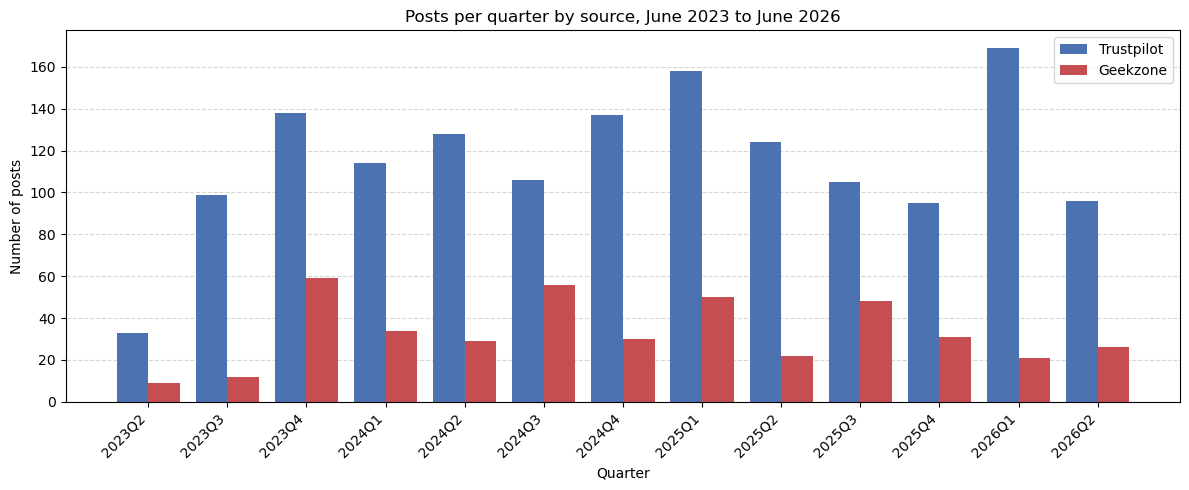

Saved geekzone_trustpilot_quarterly.png


In [3]:
import matplotlib.pyplot as plt
import numpy as np

# Use the quarterly table built earlier. The index holds the quarters.
quarters = quarterly.index.astype(str)
x = np.arange(len(quarters))  # one position on the x-axis per quarter
bar_width = 0.4

fig, ax = plt.subplots(figsize=(12, 5))

# Two bars per quarter: one for each source, offset left and right of centre.
ax.bar(x - bar_width/2, quarterly['Trustpilot'], bar_width,
       label='Trustpilot', color='#4C72B0')
ax.bar(x + bar_width/2, quarterly['Geekzone'], bar_width,
       label='Geekzone', color='#C44E52')

# Labels and title in British English.
ax.set_xlabel('Quarter')
ax.set_ylabel('Number of posts')
ax.set_title('Posts per quarter by source, June 2023 to June 2026')
ax.set_xticks(x)
ax.set_xticklabels(quarters, rotation=45, ha='right')
ax.legend()

# A light horizontal grid makes the counts easier to read off.
ax.yaxis.grid(True, linestyle='--', alpha=0.5)
ax.set_axisbelow(True)  # grid sits behind the bars

plt.tight_layout()  # stops the rotated labels being clipped

# Save the figure so it can be reused in the report, then show it.
plt.savefig('geekzone_trustpilot_quarterly.png', dpi=150, bbox_inches='tight')
plt.show()

print("Saved geekzone_trustpilot_quarterly.png")

## 4. Consolidating the Two Sources

The two datasets are combined into one. Columns present in only one source are
kept and filled with empty values for the other source, so that no information
is lost. The source column records the origin of each entry, which allows the
Trustpilot subset to be selected later for the supervised classification stage,
where a star rating is required. Trustpilot entries carry a rating and a title
and no URL, while Geekzone entries carry a URL and no rating or title, so the
combined dataset has empty values in these columns by design.

In [4]:
# Combine the two sources. pandas aligns columns by name and fills any column
# missing in one source with NaN for that source's rows. ignore_index rebuilds
# a clean row index across the combined data.
combined = pd.concat([trustpilot, geekzone], ignore_index=True, sort=False)

# Order the columns so the shared fields come first, then the source-specific
# ones.
column_order = ['provider', 'source', 'rating', 'title', 'text', 'date', 'url']
combined = combined[column_order]

print(f"Combined rows: {len(combined)}")
print()
print("Rows per source:")
print(combined['source'].value_counts())
print()
print("Rows per provider:")
print(combined['provider'].value_counts())
print()
print("Missing values per column (expected for source-specific fields):")
print(combined.isna().sum())

Combined rows: 1929

Rows per source:
source
Trustpilot    1502
Geekzone       427
Name: count, dtype: int64

Rows per provider:
provider
2degrees    734
One NZ      724
Spark       471
Name: count, dtype: int64

Missing values per column (expected for source-specific fields):
provider       0
source         0
rating       427
title        427
text           0
date           0
url         1502
dtype: int64


In [5]:
# Before removing anything, examine the duplicates so the right key is chosen.
# A duplicate by text alone might join two posts from different providers, for
# example a short "thanks, that worked" posted in two operators' forums. Removing
# by text alone would delete one of them and wrongly lower a provider's total.

# Mark every row whose text is repeated anywhere in the dataset.
dup_text_mask = combined['text'].duplicated(keep=False)
dup_rows = combined[dup_text_mask]

print(f"Rows whose text appears more than once: {len(dup_rows)}")
print()

# Among those repeated texts, how many distinct texts are there, and do any of
# them appear under more than one provider?
group = dup_rows.groupby('text')['provider'].nunique()
cross_provider_texts = group[group > 1]

print(f"Distinct repeated texts: {dup_rows['text'].nunique()}")
print(f"Repeated texts that cross providers: {len(cross_provider_texts)}")
print()

# Show a few examples of cross-provider duplicates, if any exist.
if len(cross_provider_texts) > 0:
    print("Examples of texts appearing under more than one provider:")
    for text in cross_provider_texts.index[:5]:
        providers = combined[combined['text'] == text]['provider'].tolist()
        print(f"  Providers {providers}: {text[:80]}")
else:
    print("No repeated text crosses providers.")

Rows whose text appears more than once: 0

Distinct repeated texts: 0
Repeated texts that cross providers: 0

No repeated text crosses providers.


## 5. Removing Exact Duplicates

Exact duplicate entries, where the text is identical character for character,
are removed. The check found no exact duplicates in the consolidated dataset,
so no rows are removed at this step. Partial overlap of content through quoted
replies in the Geekzone posts is handled later, in the pre-processing stage for
topic modelling, where it can be addressed on the text version intended for that
analysis. The deduplication key combines text and provider, so that a short
identical post in two providers' forums would be preserved as two legitimate
entries rather than collapsed into one.

In [6]:
rows_before = len(combined)

# Deduplicate on text and provider together, so an identical short post under
# two different providers is kept as two legitimate entries. keep='first' keeps
# the first occurrence of any true duplicate.
combined = combined.drop_duplicates(subset=['text', 'provider'], keep='first').reset_index(drop=True)

rows_after = len(combined)

print(f"Rows before deduplication: {rows_before}")
print(f"Rows after deduplication:  {rows_after}")
print(f"Exact duplicates removed:  {rows_before - rows_after}")
print()
print("Rows per provider (unchanged):")
print(combined['provider'].value_counts())

Rows before deduplication: 1929
Rows after deduplication:  1929
Exact duplicates removed:  0

Rows per provider (unchanged):
provider
2degrees    734
One NZ      724
Spark       471
Name: count, dtype: int64


## 6. Minimal Structural Cleaning

A first cleaning pass removes formatting noise that no analysis benefits from,
while preserving the features that sentiment analysis relies on. URLs are
removed, repeated whitespace and line breaks are collapsed into single spaces,
and missing spaces between sentences, common in quoted Geekzone replies such as
"What about V6?As in IPv6?", are repaired so that sentence boundaries are
readable.

Capitalisation, punctuation, stopwords and emojis are left untouched at this
stage. Sentiment analysis with VADER uses capitalisation, punctuation and
negation as intensity signals, so the text fed to it is kept close to its
original form. The heavier linguistic normalisation needed for topic modelling,
lowercasing, stopword removal and lemmatisation, is applied later in the NLP
notebook, on a separate version of the text prepared for that purpose. This
cleaned text becomes the base version stored in the database.

In [7]:
import re

def clean_structural(text):
    """
    Apply minimal structural cleaning to a single text.

    This removes formatting noise only. It does not lowercase, strip
    punctuation, remove stopwords or remove emojis, because those features are
    either needed by VADER or handled later for topic modelling.

    Steps:
      1. Remove URLs (http, https and www links).
      2. Repair missing spaces after sentence punctuation, where a full stop,
         question mark or exclamation mark is immediately followed by a letter,
         as happens in quoted Geekzone replies.
      3. Collapse any run of whitespace, including line breaks, into one space.
      4. Trim leading and trailing spaces.
    """
    text = str(text)

    # 1. Remove URLs. The pattern matches http:// or https:// or www. followed
    #    by non-space characters.
    text = re.sub(r'(https?://\S+|www\.\S+)', ' ', text)

    # 2. Repair a missing space where sentence punctuation is glued to the next
    #    word. For example 'V6?As' becomes 'V6? As'. The pattern looks for . ? or
    #    ! directly followed by an upper or lower case letter, and inserts a
    #    space between them.
    text = re.sub(r'([.?!])([A-Za-z])', r'\1 \2', text)

    # 3. Collapse all whitespace runs (spaces, tabs, newlines) into one space.
    text = re.sub(r'\s+', ' ', text)

    # 4. Remove leading and trailing spaces.
    text = text.strip()

    return text


# Apply to every row, storing the result in a new column so the original text
# is preserved for reference and traceability.
combined['text_clean'] = combined['text'].apply(clean_structural)

print("Structural cleaning applied.")
print(f"Rows processed: {len(combined)}")
print()

# Show a few before-and-after examples to confirm the cleaning behaves as
# intended, choosing Geekzone rows where quoting is likely.
sample = combined[combined['source'] == 'Geekzone'].head(3)
for row in sample.itertuples(index=False):
    print("BEFORE:", row.text[:150])
    print("AFTER: ", row.text_clean[:150])
    print("-" * 70)

Structural cleaning applied.
Rows processed: 1929

BEFORE: Hi I look after the SIP platform that MyRepublic voice services are being migrated to.Your Phone number and password will not change as part of the mi
AFTER:  Hi I look after the SIP platform that MyRepublic voice services are being migrated to. Your Phone number and password will not change as part of the m
----------------------------------------------------------------------
BEFORE: Hi Kevin.Most of the above didn't make a lot of sense to me, but I assume it was about the landline phone service MyRepublic provide to their broadban
AFTER:  Hi Kevin. Most of the above didn't make a lot of sense to me, but I assume it was about the landline phone service MyRepublic provide to their broadba
----------------------------------------------------------------------
BEFORE: The ONT phone lines will be migrated on the day that your Broadband migrates.ONT and ATA voice are provided on the same platform so should behave the 
AFTER:  The 

In [8]:
# Check whether the space-repair rule split anything that should have stayed
# together. We look for short fragments that may signal a broken abbreviation,
# for example a single capital letter left stranded between spaces, which can
# happen with patterns like 'U.S.A' becoming 'U. S. A'.
import re

# Count rows where the cleaned text contains a lone single capital letter
# surrounded by spaces, a possible sign of a split abbreviation.
suspicious = combined['text_clean'].apply(
    lambda t: bool(re.search(r'\s[A-Z]\.\s', str(t)))
)

print(f"Rows with a possibly split abbreviation: {suspicious.sum()}")
print()

# Show a few examples if any exist, so they can be judged by eye.
if suspicious.sum() > 0:
    for row in combined[suspicious].head(5).itertuples(index=False):
        print(row.text_clean[:160])
        print("-" * 70)
else:
    print("No obvious split abbreviations found.")

Rows with a possibly split abbreviation: 8

Came into spark shop (N. P. Devonstreet) to buy a Nokia 2660 Flip Back phone, service agent VERY unhelpfull, when asked whether the phone was "predictive textin
----------------------------------------------------------------------
I'm in the U. S. and have business interests in New Zealand. I got a NZ mobile number to add as an eSim to my iPhone. This worked for a while - with initial pro
----------------------------------------------------------------------
Topped up my pre pay and it said there's been a problem please check your bank before trying again. So I wait 2 hours check my bank and yes they have taken my m
----------------------------------------------------------------------
I bought a top up for my one. nz prepay using their app. It took my payment but didn't apply the top up to my phone. I rang them the next day and their AI robot
----------------------------------------------------------------------
I am a customer of 2Degrees 

## 7. Final Text Quality Check

Before the data is stored, the cleaned text is checked for quality. Empty or
near-empty entries are identified, and the word count of each entry is computed
so that the minimum length criterion can be confirmed. The inclusion criteria
require each entry to contain at least twenty words, so that there is enough
content for sentiment analysis and topic modelling. Entries falling below this
length after cleaning are reported, so that the effect of applying the criterion
to the consolidated dataset is visible.

In [9]:
# Count words in the cleaned text by splitting on whitespace.
combined['word_count'] = combined['text_clean'].apply(lambda t: len(str(t).split()))

print("Word count summary:")
print(combined['word_count'].describe())
print()

# Check for empty or near-empty entries after cleaning.
empty = (combined['word_count'] == 0).sum()
print(f"Empty entries after cleaning: {empty}")
print()

# Count entries below the 20-word minimum, by source.
below_min = combined[combined['word_count'] < 20]
print(f"Entries below 20 words: {len(below_min)}")
print()
print("Below-minimum entries by source:")
print(below_min['source'].value_counts())
print()
print("Below-minimum entries by provider:")
print(below_min['provider'].value_counts())

Word count summary:
count    1929.000000
mean       88.108865
std        87.649626
min         1.000000
25%        37.000000
50%        63.000000
75%       109.000000
max       969.000000
Name: word_count, dtype: float64

Empty entries after cleaning: 0

Entries below 20 words: 181

Below-minimum entries by source:
source
Trustpilot    136
Geekzone       45
Name: count, dtype: int64

Below-minimum entries by provider:
provider
One NZ      82
2degrees    59
Spark       40
Name: count, dtype: int64


In [10]:
# Confirm the current state of the consolidated dataset before saving.
print("Dataset ready to store:")
print(f"  Rows: {len(combined)}")
print(f"  Columns: {list(combined.columns)}")
print()
print("Column types:")
print(combined.dtypes)
print()
print("Any missing values:")
print(combined.isna().sum())

Dataset ready to store:
  Rows: 1929
  Columns: ['provider', 'source', 'rating', 'title', 'text', 'date', 'url', 'text_clean', 'word_count']

Column types:
provider              object
source                object
rating               float64
title                 object
text                  object
date          datetime64[ns]
url                   object
text_clean            object
word_count             int64
dtype: object

Any missing values:
provider         0
source           0
rating         427
title          427
text             0
date             0
url           1502
text_clean       0
word_count       0
dtype: int64


## 8. Storing the Data in SQLite

The consolidated and cleaned dataset is stored in a local SQLite database before
the NLP pipeline reads it. SQLite is a self-contained relational database held in
a single file, requiring no separate server, and it is part of the Python
standard library, so no installation is needed. Storing structured data in a
relational database before it enters a machine learning pipeline mirrors standard
industry practice, where data is held in a database rather than in loose files,
and it supports exploratory queries and aggregation before modelling.

The dataset is written to a table named `reviews`, holding all fields, so that
the NLP notebook can read both the original and the cleaned text from a single
structured source.

In [11]:
import sqlite3

# Open a connection to the database file. If the file does not exist yet,
# SQLite creates it. The file will sit in the same folder as this notebook.
# Think of this as opening the database so we can write to it.
connection = sqlite3.connect('telecom_reviews.db')

# Write the DataFrame to a table called 'reviews'.
#   name='reviews'        -> the table will be called reviews
#   con=connection        -> use the connection we just opened
#   if_exists='replace'   -> if the table already exists, replace it, so that
#                            re-running this cell does not stack duplicate rows
#   index=False           -> do not write pandas' own row numbers as a column
combined.to_sql('reviews', con=connection, if_exists='replace', index=False)

# Make sure the changes are saved to the file, then close the connection.
# commit() writes the changes to disk; close() releases the file.
connection.commit()
connection.close()

print("Data stored in telecom_reviews.db, table 'reviews'.")
print(f"Rows written: {len(combined)}")

Data stored in telecom_reviews.db, table 'reviews'.
Rows written: 1929


## 9. Exploratory Queries with SQL

Before modelling, the dataset is explored through SQL queries run against the
database. These queries report the volume of reviews per provider, the
distribution of star ratings, and the split between the two sources. Running
these as SQL, rather than in pandas alone, uses the relational structure of the
stored data and reflects how exploration is carried out in a setting where the
data resides in a database.

In [12]:
import sqlite3
import pandas as pd

# Open the connection again, this time to read from the database.
connection = sqlite3.connect('telecom_reviews.db')

# Our first query: count how many reviews each provider has.
# pd.read_sql runs the SQL query against the database and returns the result
# as a DataFrame, so the output is easy to read in the notebook.
query = """
SELECT provider, COUNT(*) AS review_count
FROM reviews
GROUP BY provider
ORDER BY review_count DESC
"""
result = pd.read_sql(query, connection)
print("Reviews per provider:")
print(result)

Reviews per provider:
   provider  review_count
0  2degrees           734
1    One NZ           724
2     Spark           471


In [13]:
# Reviews per provider, Trustpilot only.
# WHERE source = 'Trustpilot' keeps only Trustpilot rows before counting.
query = """
SELECT provider, COUNT(*) AS review_count
FROM reviews
WHERE source = 'Trustpilot'
GROUP BY provider
ORDER BY review_count DESC
"""
result = pd.read_sql(query, connection)
print("Reviews per provider (Trustpilot only):")
print(result)

Reviews per provider (Trustpilot only):
   provider  review_count
0    One NZ           596
1  2degrees           590
2     Spark           316


In [14]:
# Reviews per provider AND source, the two sources shown side by side.
# Grouping by two columns counts each combination of provider and source.
query = """
SELECT provider, source, COUNT(*) AS review_count
FROM reviews
GROUP BY provider, source
ORDER BY provider, source
"""
result = pd.read_sql(query, connection)
print("Reviews per provider and source:")
print(result)

Reviews per provider and source:
   provider      source  review_count
0  2degrees    Geekzone           144
1  2degrees  Trustpilot           590
2    One NZ    Geekzone           128
3    One NZ  Trustpilot           596
4     Spark    Geekzone           155
5     Spark  Trustpilot           316


In [15]:
# Distribution of star ratings, Trustpilot only (Geekzone has no rating).
# We filter to Trustpilot because rating is empty for Geekzone rows.
query = """
SELECT rating, COUNT(*) AS count
FROM reviews
WHERE source = 'Trustpilot'
GROUP BY rating
ORDER BY rating
"""
result = pd.read_sql(query, connection)
print("Rating distribution (Trustpilot only):")
print(result)

Rating distribution (Trustpilot only):
   rating  count
0     1.0   1296
1     2.0     34
2     3.0     19
3     4.0     14
4     5.0    139
